# 01 — Stationarity and cointegration

Two stocks can be highly correlated and still not form a tradeable pair. Correlation is about *returns
moving together day to day*; what a pairs trade needs is a **spread that reverts to a stable mean** — a
property of the *price levels*, not the returns. That property is **cointegration**, and this notebook is
about testing for it honestly.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statarb import data, stats, signals

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE, GREY, VERM = "#0072B2", "#E69F00", "#8A8F98", "#D55E00"
px = data.align_prices(pd.read_csv("../data/semis.csv", index_col=0, parse_dates=True))

## Unit roots and the ADF test

A price series is (close to) a random walk: it has a **unit root** and wanders without returning to any
level — it is *non-stationary*. A tradeable spread must be the opposite: *stationary*, pulled back toward
its mean. The Augmented Dickey–Fuller (ADF) test formalises this. Its null hypothesis is "has a unit root
(non-stationary)", so a **small p-value means stationary**.

A single price should fail the test (large p); the interesting question is whether some *combination* of
two prices passes it.

In [2]:
a, b = "AMAT", "LRCX"
ly, lx = np.log(px[a]), np.log(px[b])
print(f"ADF on log {a}: p = {stats.adf_test(ly).pvalue:.2f}   (large -> non-stationary, as expected)")
print(f"ADF on log {b}: p = {stats.adf_test(lx).pvalue:.2f}")

ADF on log AMAT: p = 0.70   (large -> non-stationary, as expected)
ADF on log LRCX: p = 0.73


## Engle–Granger: is the spread stationary?

The Engle–Granger recipe is two steps. First regress one log price on the other to get a **hedge ratio**
$\beta$; the residual is the spread
$$s_t = y_t - (\alpha + \beta x_t).$$
Then run the ADF test on that spread. If the spread is stationary, the pair is cointegrated and $s_t$ is
the thing we trade. `engle_granger` does both and returns the test result together with $\beta$.

AMAT~LRCX:  hedge ratio beta = 0.868   EG p-value = 0.305


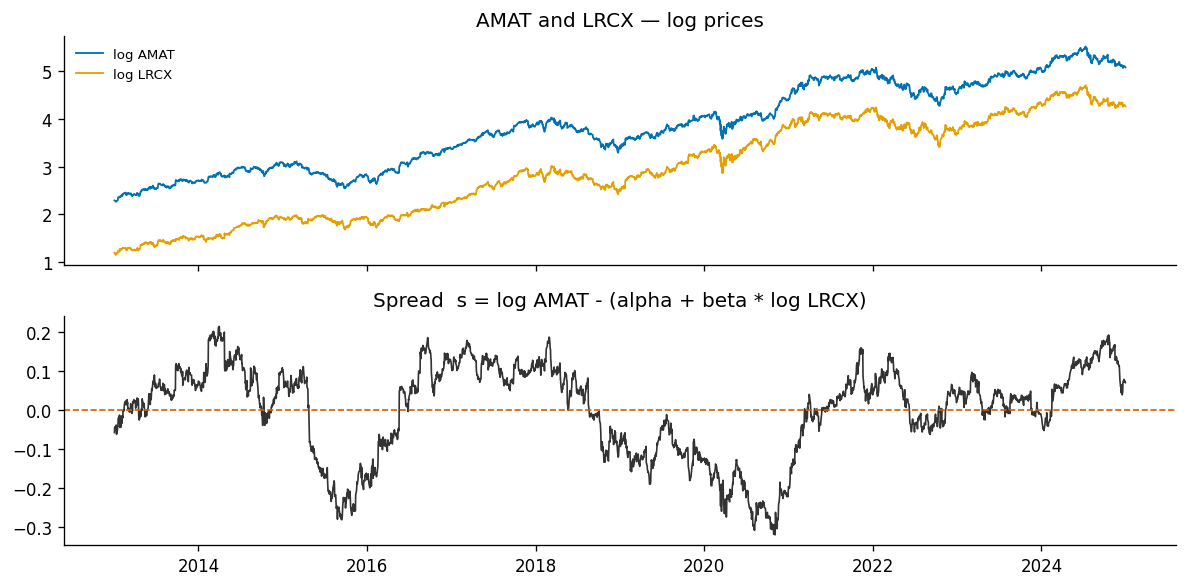

In [3]:
eg = stats.engle_granger(ly, lx)
spread = signals.spread(ly, lx)
print(f"{a}~{b}:  hedge ratio beta = {eg.hedge_ratio:.3f}   EG p-value = {eg.pvalue:.3f}")

fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
a1.plot(ly.index, ly, color=BLUE, lw=1.1, label=f"log {a}")
a1.plot(lx.index, lx, color=ORANGE, lw=1.1, label=f"log {b}")
a1.legend(frameon=False, fontsize=8); a1.set_title(f"{a} and {b} — log prices")
a2.plot(spread.index, spread, color="#333", lw=1.0); a2.axhline(spread.mean(), ls="--", color=VERM, lw=1)
a2.set_title(f"Spread  s = log {a} - (alpha + beta * log {b})")
plt.tight_layout(); plt.show()

## The multiple-testing trap

It is tempting to test every pair and trade whichever looks most cointegrated. But with $\binom{n}{2}$
tests, roughly $5\%$ will clear a raw $5\%$ threshold *by chance alone*. `screen_pairs` runs every pair
and then applies a **Benjamini–Hochberg FDR** correction so the p-values are honest about how many tests
were run. On the semiconductor universe the result is stark.

In [4]:
scr = stats.screen_pairs(px, alpha=0.05)
n = scr.attrs["n_tests"]
print(f"pairs tested: {n}")
print(f"significant at raw 5%:  {int(scr['significant_raw'].sum())}   (~{n*0.05:.0f} expected by chance)")
print(f"significant after FDR:  {int(scr['significant_adj'].sum())}")
scr.head(5)[["y", "x", "pvalue", "pvalue_adj", "hedge_ratio"]].round(4)

pairs tested: 210
significant at raw 5%:  10   (~10 expected by chance)
significant after FDR:  0


,y,x,pvalue,pvalue_adj,hedge_ratio
0,ADI,LRCX,0.0104,0.8426,0.5731
1,LRCX,SOXX,0.0110,0.8426,1.2537
2,ADI,SOXX,0.0213,0.8426,0.7245
3,MRVL,QCOM,0.0238,0.8426,1.4013
4,LRCX,MCHP,0.0267,0.8426,1.7016


Ten pairs clear the raw bar — almost exactly the $\approx 10$ that pure chance predicts — and **none**
survive the correction. Over this window the sector shows no statistically robust cointegration.

## Correlation is not cointegration

The cleanest illustration is the pair of near-identical semiconductor ETFs, SMH and SOXX. Their daily
returns are almost perfectly correlated, yet their price spread slowly drifts apart (different weightings
compound over a decade), so it is *not* stationary — and the pair is not cointegrated.

SMH/SOXX daily-return correlation: 0.988
cointegrated?  False  (EG p = 1.00)


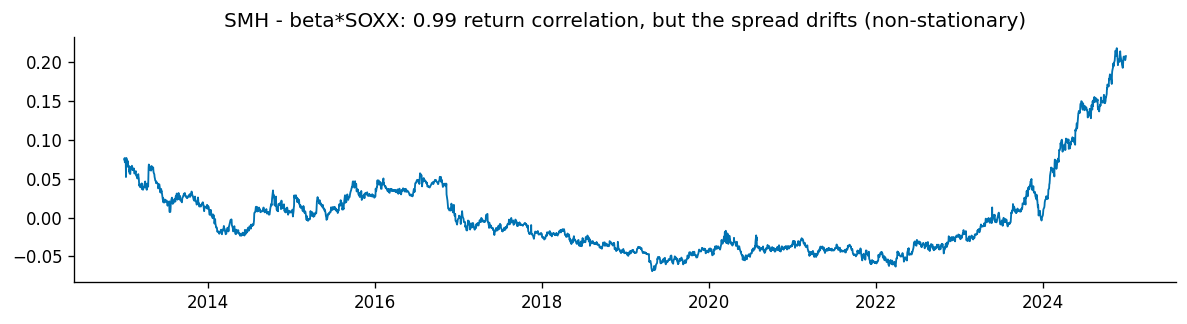

In [5]:
ret_corr = px[["SMH", "SOXX"]].pct_change().dropna().corr().iloc[0, 1]
eg_etf = stats.engle_granger(np.log(px["SMH"]), np.log(px["SOXX"]))
sp = signals.spread(np.log(px["SMH"]), np.log(px["SOXX"]))
print(f"SMH/SOXX daily-return correlation: {ret_corr:.3f}")
print(f"cointegrated?  {eg_etf.is_cointegrated}  (EG p = {eg_etf.pvalue:.2f})")

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.plot(sp.index, sp, color=BLUE, lw=1.1)
ax.set_title("SMH - beta*SOXX: 0.99 return correlation, but the spread drifts (non-stationary)")
plt.tight_layout(); plt.show()

So cointegration is the property that actually matters, correlation is not enough, and a screen only
means something once it is corrected for multiple testing. The next notebook turns a cointegrated spread
into a trading signal.